### What is simple linear regression?

Simple regression means to predict one continuous variable from another


$y_i = \beta_0 + \beta_1 x_i + \epsilon_i$

  $   = \sigma (w_0 + x^T w)$

  $   = \sigma(x^T w)$

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

/tmp/ipykernel_4277/2026922495.py:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


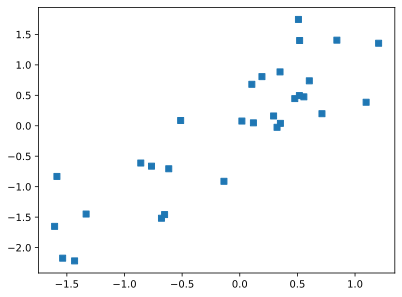

In [3]:
N = 30
x = torch.randn(N, 1)
y = x + torch.randn(N,1)/2


plt.plot(x, y, 's')
plt.show()

In [12]:
AnnReg = nn.Sequential(
    nn.Linear(1, 1),
    nn.ReLU(),
    nn.Linear(1, 1),
)

AnnReg

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
)

In [13]:
learning_rate = 0.05
loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(AnnReg.parameters(), lr=learning_rate)

In [14]:
num_epochs = 500
losses = torch.zeros(num_epochs)


for i in range(num_epochs):
  y_hat = AnnReg(x)

  loss = loss_fn(y_hat, y)
  losses[i] = loss

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

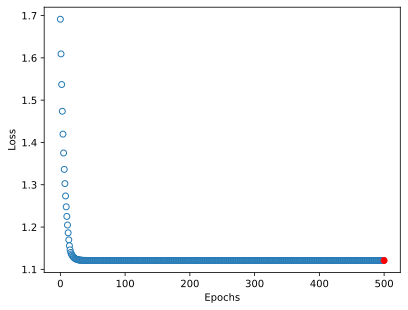

In [15]:
predictions = AnnReg(x)


test_loss = (predictions-y).pow(2).mean()

plt.plot(losses.detach(), 'o', markerfacecolor='w', linewidth=.1)
plt.plot(num_epochs, test_loss.detach(), 'ro')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

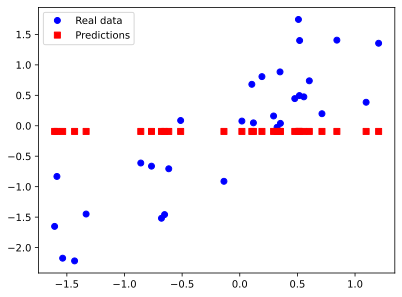

In [16]:
plt.plot(x, y, 'bo', label='Real data')
plt.plot(x, predictions.detach(), 'rs', label='Predictions')
plt.legend()
plt.show()